In [1]:
# load Python packages
import numpy as np  # for numerical python libraries
import matplotlib.pyplot as plt  # for plotting
import scipy.stats as stats

In [ ]:
# Tests
# X = np.array([[1, 2], [3, 4]])
# #X[0,:] = 1; print(X)
# print(X); print(X[1,0]); print(X[1, :])
# sum(X[1,:])

# tmp = "rah" != "blah"; tmp * 2

# type = "rah"
# if type == "Merton":
#     def jump(x): 1
# elif type == "Kou":
#     def jump(x): 1
# else:
#     def jump(): return 0

# print(type)
# print(jump())

# U = stats.uniform.rvs(); print(U)
# jump = U < (1 - np.exp(-1 * 1)); print(jump)  # interarrival times exponentially dist
# jump_size = stats.gamma.rvs(a=1, scale=1, size=1); print(jump_size)

# A = B = 3; print(A); print(B)

# print(np.zeros(3))
# for i in range(5):
    # print(i)

np.random.binomial(1, 0.5)

0

In [ ]:
## Rough Work
        # jump_size = np.exp(np.random.normal(loc=m, scale=delta, size=Nsims))
        # X[idx+1,:] = X[idx,:] * np.exp((r - sigma**2 / 2 - lam*(np.exp(m + delta**2 / 2) - 1)) * dt +
        #                                sigma * np.sqrt(dt) * Z +
        #                                jump * jump_size)

## Simulation

--
$$
\begin{aligned}
    S_t &= (r - \frac{\sigma^2}{2} - \lambda (e^{m + \frac{\delta^2}{2}} - 1))t + \sigma B_t + \sum_{i=1}^{N_t} Y_i \\
    dS_t &= \mu S_t dt + \sigma S_t dW_t
\end{aligned}
$$

where $B_t$ is standard Brownian motion, $Y_i \sim i.i.d. Lognormal(m, \delta^2)$, and $N_t$ is a poisson process with intensity $\lambda$.

In [84]:
# Helper functions: Black-Scholes
def sim_jump_diffusion(X0, T, Ndt, r, sigma, Nsims = 100, type = "BS", lam = 0, m = 0, delta = 0):
    ## Basic parameters
    dt = T / Ndt # create time increment
    time = np.linspace(0, T, Ndt+1) # set the different times as a vector
    X = B = np.zeros((Ndt+1,Nsims)) # initialize matrix
    X[0,:] = X0 # initial value of the process
    
    ## Process-specific value(s) + jump simulation function
    merton = 0
    if type == "Merton":
        # Merton: Drift adjustment
        merton = lam * (np.exp(m + delta**2 / 2) - 1)

        # Generate jumps
        def jump_distn():
            # Number of jumps - Poisson process
            U = stats.uniform.rvs(size=Nsims)
            jump = U < (1 - np.exp(-lam * dt))  # Interarrival times exponentially dist
            # Jump size - Normal distribution
            jump_size = np.random.normal(loc=m, scale=delta, size=Nsims) # Jump size normally distributed
            return jump * jump_size
        
    elif type == "Kou":
        def jump_distn():
            # Number of jumps
            U = stats.uniform.rvs(size=Nsims)
            jump = U < (1 - np.exp(-lam * dt))
            # Jump size
            B = np.random.binomial(n = 1, p = m, size = Nsims) # Bernoulli rv - whether jump is positive or negative
            jump_size = np.zeros(Nsims)
            for i in range(Nsims):
                jump_size[i] = (-1)**(B[i] + 1) * np.random.exponential(1/delta[B[i]]) # Jump size exponentially distributed
            return jump * jump_size
        
    else: # Black-Scholes
        def jump_distn(): return 0 # No jumps
    
    ## Simulation
    for idx in range(Ndt):
        Z = np.random.randn(Nsims)
        X[idx+1,:] = X[idx,:] + (r - sigma**2 / 2 - merton) * dt + sigma * np.sqrt(dt) * Z + jump_distn()
    
    return time, X

## Black-Scholes

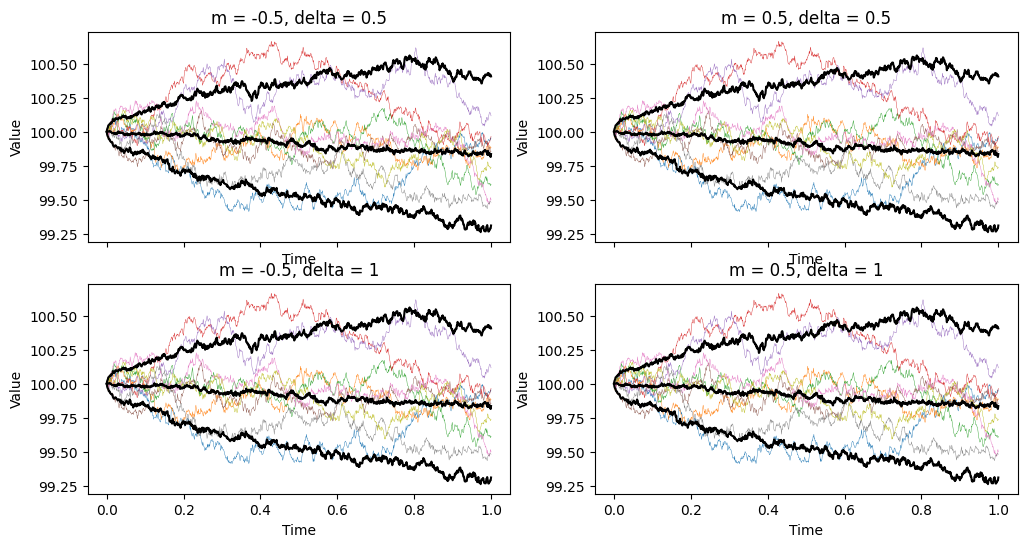

In [85]:
# Parameters
X0 = 100
r = 0.05
sigma = 0.5
T = 1
Ndt = 1000
Nsims = 100

# Figures
fig, axes = plt.subplots(2, 2, figsize=(12,6), sharex=True)
for idx_row, row in enumerate(axes):
    for idx_col, col in enumerate(row):
        np.random.seed(2502)
        t, price = sim_jump_diffusion(X0, T, Ndt, r, sigma, Nsims)#, "Merton", lam, m[idx_row], delta[idx_col])
        
        # plot the sample paths
        col.plot(t, price[:,1:10], linewidth=0.3)
        col.plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
                  linewidth=1.5, color='black')
        col.set_title(r"m = " + str(m[idx_col]) + r", delta = " + str(delta[idx_row]))
        col.set_xlabel('Time')
        col.set_ylabel('Value')
plt.show()

## Merton

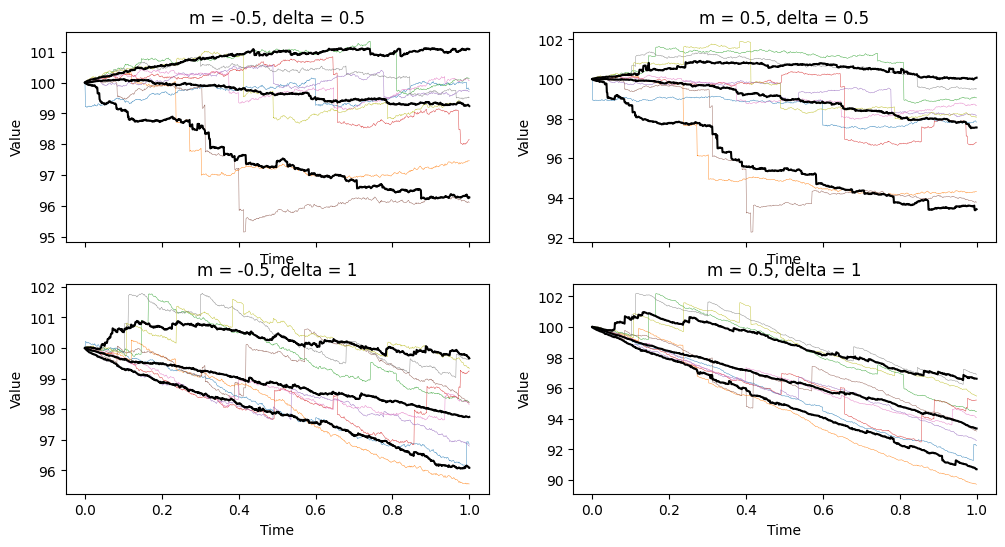

In [86]:
# Parameters
X0 = 100
r = 0.05
sigma = 0.5
lam = 5
m = [-0.5, 0.5]
delta = [0.5, 1]
T = 1
Ndt = 1000
Nsims = 100

# Figures
fig, axes = plt.subplots(2, 2, figsize=(12,6), sharex=True)
for idx_row, row in enumerate(axes):
    for idx_col, col in enumerate(row):
        np.random.seed(2502)
        t, price = sim_jump_diffusion(X0, T, Ndt, r, sigma, Nsims, "Merton", lam, m[idx_row], delta[idx_col])
        
        # plot the sample paths
        col.plot(t, price[:,1:10], linewidth=0.3)
        col.plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
                  linewidth=1.5, color='black')
        col.set_title(r"m = " + str(m[idx_col]) + r", delta = " + str(delta[idx_row]))
        col.set_xlabel('Time')
        col.set_ylabel('Value')
plt.show()

## Kou

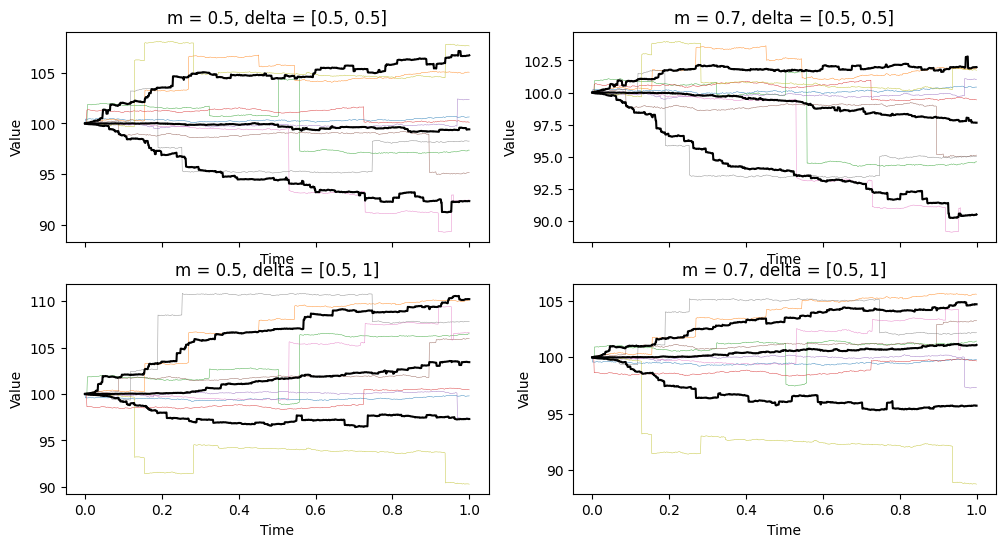

In [88]:
# Parameters
X0 = 100
r = 0.05
sigma = 0.5
lam = 5
m = [0.5, 0.7]
delta = [[0.5, 0.5], [0.5, 1]]
T = 1
Ndt = 1000
Nsims = 100

# Figures
fig, axes = plt.subplots(2, 2, figsize=(12,6), sharex=True)
for idx_row, row in enumerate(axes):
    for idx_col, col in enumerate(row):
        np.random.seed(2502)
        t, price = sim_jump_diffusion(X0, T, Ndt, r, sigma, Nsims, "Kou", lam, m[idx_row], delta[idx_col])
        
        # plot the sample paths
        col.plot(t, price[:,1:10], linewidth=0.3)
        col.plot(t, np.quantile(price, [0.1, 0.5, 0.9], axis=1).transpose(), 
                  linewidth=1.5, color='black')
        col.set_title(r"m = " + str(m[idx_col]) + r", delta = " + str(delta[idx_row]))
        col.set_xlabel('Time')
        col.set_ylabel('Value')
plt.show()